In [1]:
import pandas as pd

df = pd.read_csv('../datasets/redmi6.csv', encoding='windows-1252')

In [2]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
77,Awesome phone,Amazon Customer,5.0 out of 5 stars,on 19 September 2018,Display,Phone is good Quality Dual Camera is Very Best...,
37,Bad camera,JAWED HUSSAIN,2.0 out of 5 stars,on 21 September 2018,Camera,Bad camera quality and heating problem,2 people found this helpful
7,Fantastic,Amazon Customer,4.0 out of 5 stars,on 18 September 2018,Camera,Front camera is poor rest things are good,5 people found this helpful
252,I love mi 6 pro,Anuj kr gupta,5.0 out of 5 stars,on 18 September 2018,Battery,Osm product\nAmazon is better then flipkart I ...,NaN
232,Best phone forever.,Manish Singh,5.0 out of 5 stars,on 18 September 2018,Others,Best phone with face unlock full hd video reco...,NaN
249,average phone,sarfaraz alam,3.0 out of 5 stars,on 25 September 2018,Battery,after using two weeks i just analyse that it i...,
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
217,Super,Jawed Ansari,5.0 out of 5 stars,on 26 September 2018,Others,Good,NaN
235,Don't buy this mobile mi 6 pro,Vasudevan,1.0 out of 5 stars,on 15 September 2018,Display,"Very poor quality in front facing camera, and ...",NaN
50,Best Mobile in this price category.,Rahul.K.R,4.0 out of 5 stars,on 2 October 2018,Battery,"Nice mobile, battery backup is good, camera gu...",One person found this helpful


In [3]:
df.isnull().sum()

# We don't use 'Useful' column, so no problem with missing values

Review Title       0
Customer name      0
Rating             0
Date               0
Category           0
Comments           0
Useful           170
dtype: int64

In [4]:
df['Rating'] = df['Rating'].str.split(' ', expand=True)[0]

In [5]:
df['Rating'].unique().tolist()

['4.0', '3.0', '5.0', '2.0', '1.0']

In [6]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
175,Value of money,Ahir Dipak Ram,4.0,on 20 September 2018,Others,Superb product,NaN
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful
58,Trust or not trust as your wish,Mayur shingne,5.0,on 28 September 2018,Display,This product is very nice and battery life and...,2 people found this helpful
62,Good budget phone,Vinamra,4.0,on 1 October 2018,Battery,Works pretty good for a budget phone. Battery ...,
213,Best display and advance features,Girish Basone,5.0,on 18 September 2018,Others,Nice,NaN
257,Value for money...,Amazon Customer,5.0,on 17 September 2018,Camera,Working good with Snapdragon 625 which is its ...,NaN
126,Superb,Rishad,5.0,on 21 September 2018,Others,Good,NaN
233,"Not impressive, Y2 is better",Mudasar Nazar,2.0,on 18 September 2018,Others,Overall Phone seems to be good with performanc...,NaN
216,Launch display,pintu sahoo,5.0,on 24 September 2018,Others,Ok,NaN
43,Not good as expected,Bidyut Majumder,1.0,on 20 September 2018,Others,Do not buy.,One person found this helpful


In [7]:
df = df[['Rating', 'Comments', 'Category']]

In [8]:
# Check for missing values

df.isnull().sum()

Rating      0
Comments    0
Category    0
dtype: int64

In [9]:
df.sample(10)

,Rating,Comments,Category
47,2.0,Bad camera quality and heating problem,Camera
134,1.0,Bad facility for replacement,Others
84,5.0,Picture perfect camera\nGreat sound\nGood batt...,Battery
235,1.0,"Very poor quality in front facing camera, and ...",Display
2,3.0,Quite good,Others
135,5.0,I've fallen in love!,Others
46,4.0,Nice product. Delivery guy also.,Delivery
128,4.0,Nice mobile in this price range,Others
232,5.0,Best phone with face unlock full hd video reco...,Others
67,5.0,Midrange phone with a notch...and brand like M...,Others


In [10]:
df.count()

Rating      280
Comments    280
Category    280
dtype: int64

In [11]:
# This code is used to categorize comments into different sentiment categories using the Ollama API (with qwen2.5-coder:latest model).

from tqdm import tqdm
import ollama
import time

# Add a progress bar
for i in tqdm(range(len(df)), desc="Processing comments"):
    comment = df.loc[i, 'Comments']
    comment_category = 'Unknown'

    try:
        response = ollama.generate(
            model='qwen2.5-coder:latest',  
            prompt=f"Categorize the following comment into exactly one of these categories: Very Negative, Negative, Neutral, Positive, Very Positive. Comment: {comment}"
        )
        
        result = response['response'].strip()
        if result in ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']:
            comment_category = result
            
    except Exception as e:
        print(f"Error processing comment {i}: {str(e)}")
        
    df.loc[i, 'Comment Categories'] = comment_category
    
    # Add a small delay to avoid overwhelming the API
    time.sleep(0.1)

Processing comments: 100%|██████████| 280/280 [08:37<00:00,  1.85s/it]


In [12]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
dtype: int64

In [14]:
df['Comment Categories'].unique().tolist()

['Unknown',
 'Negative',
 'Positive',
 'Neutral',
 'Very Negative',
 'Very Positive']

In [15]:
# Only load data that Comment Category equals to 'Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive', avoid 'Unknown' 
df = df[df['Comment Categories'].isin(['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])]

In [16]:
df['Comment Categories'].unique().tolist()

['Negative', 'Positive', 'Neutral', 'Very Negative', 'Very Positive']

In [17]:
df.count()

Rating                248
Comments              248
Category              248
Comment Categories    248
dtype: int64

In [18]:
# Change data type
df.loc[:,'Rating'] = df['Rating'].astype(float)

In [19]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating'].map({5.0: 'Very Positive', 4.0: 'Positive', 3.0: 'Neutral', 2.0: 'Negative', 1.0: 'Very Negative'}) 

In [20]:
df.sample(10)

,Rating,Comments,Category,Comment Categories,Rating Categories
257,5.0,Working good with Snapdragon 625 which is its ...,Camera,Positive,Very Positive
22,4.0,Like every things but fullscreen video playing...,Others,Negative,Positive
60,5.0,Battery life is awesome including display is t...,Display,Positive,Very Positive
267,1.0,Phone has heating issue. Amazon return policy ...,Others,Negative,Very Negative
130,3.0,Average,Others,Neutral,Neutral
21,4.0,"Very nice looks , smooth operation , camera co...",Camera,Positive,Positive
157,5.0,I have fall in love,Others,Positive,Very Positive
214,5.0,Ok,Others,Neutral,Very Positive
50,4.0,"Nice mobile, battery backup is good, camera gu...",Battery,Positive,Positive
11,3.0,All ok but vry small size mobile,Others,Negative,Neutral


In [21]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [22]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

               Rating Categories Count  Comment Categories Count
Very Positive                      146                         2
Positive                            43                       166
Very Negative                       29                        13
Neutral                             22                        24
Negative                             8                        43


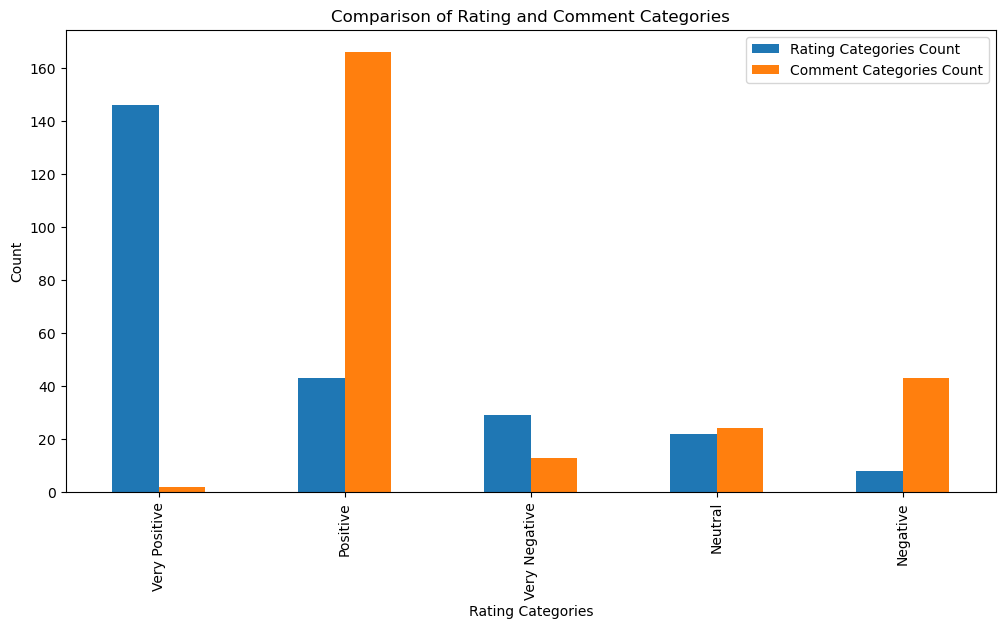

In [23]:
import matplotlib.pyplot as plt

# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

In [24]:
# Get the mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 187


In [25]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'}) 

In [26]:
# Do mapping Comment Categories
df.loc[:, 'Comment Categories'] = df['Comment Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'})

In [27]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [28]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

          Rating Categories Count  Comment Categories Count
Positive                      189                       168
Negative                       37                        56
Neutral                        22                        24


In [29]:
# Get mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 46


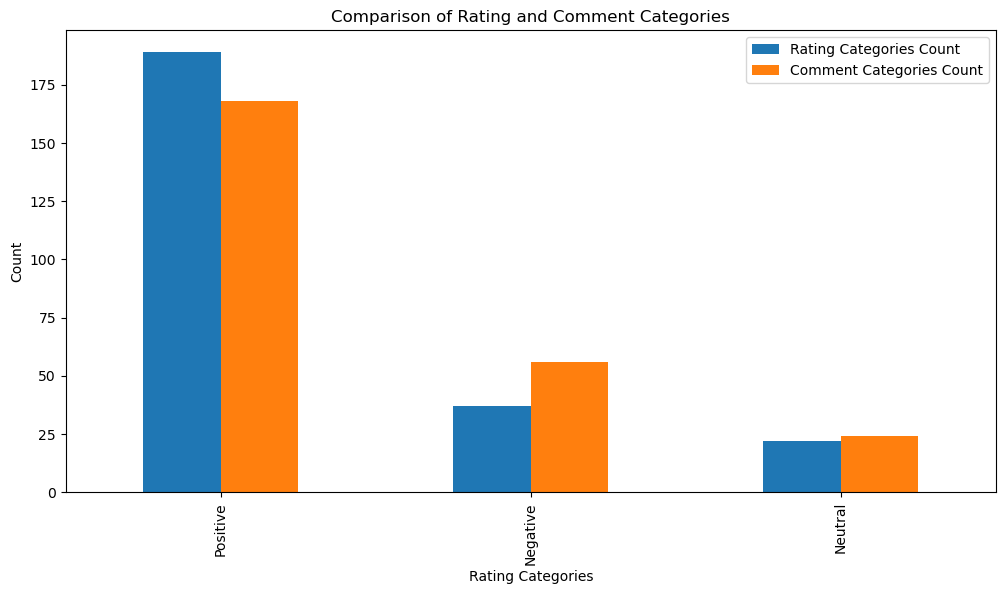

In [30]:
# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

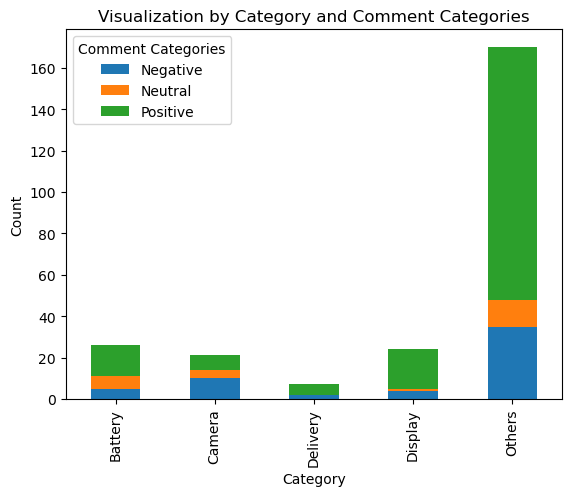

In [31]:
# Create pivot table
pivot_table = df.pivot_table(index='Category', columns='Comment Categories', aggfunc='size', fill_value=0)

# Display the pivot table
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Visualization by Category and Comment Categories')
plt.show()

In [32]:
df

,Rating,Comments,Category,Comment Categories,Rating Categories
1,3.0,All ok but vry small size mobile,Others,Negative,Neutral
2,3.0,Quite good,Others,Positive,Neutral
3,5.0,Redmi has always have been the the king of bud...,Display,Positive,Positive
4,2.0,worst product from MI. I am a hardcore fan of ...,Others,Negative,Negative
6,4.0,Pros:\nnotch display\nDual camera\nFace unlock...,Display,Positive,Positive
...,...,...,...,...,...
273,1.0,Charging issue\nLagging issue\nhanging issue\n...,Battery,Neutral,Negative
274,3.0,Nice product\nFront or rear camera thoda accha...,Camera,Neutral,Neutral
275,5.0,"I like This Phone, Awesome look and design.\nI...",Others,Positive,Positive
276,4.0,Product is avasome but invoice is note include...,Others,Negative,Positive
